In [10]:
import optuna
from optuna.importance import get_param_importances, PedAnovaImportanceEvaluator

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [2]:
study = optuna.load_study(
    study_name="Model Train",
    storage="sqlite:///../../database.db"
)

In [3]:
importances = get_param_importances(
    study,
    evaluator=PedAnovaImportanceEvaluator(),
    target=lambda t: t.value
)

importances

/tmp/ipykernel_12095/1418250384.py:3: ExperimentalWarning: PedAnovaImportanceEvaluator is experimental (supported from v3.6.0). The interface can change in the future.
  evaluator=PedAnovaImportanceEvaluator(),
/home/flobo/anaconda3/envs/Grover/lib/python3.13/site-packages/optuna/importance/_ped_anova/evaluator.py:148: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  warnings.warn(


{'lr': 0.306536174294282,
 'num_layers': 0.1240140038997745,
 'log2_num_heads': 0.11914897300478058,
 'scheduler': 0.11294880401260513,
 'epochs': 0.09797533056567173,
 'final_activation': 0.0726631527217144,
 'dropout': 0.052101688353905086,
 'activation_1': 0.04438266279009647,
 'log2_embed_size': 0.043585945724163896,
 'pooling': 0.014962695302119453,
 'log2_layer_0': 0.011680569330886768}

In [4]:
data = pd.DataFrame(
        list(importances.items()),
        columns=["hyperparameter", "importance"]
      ).sort_values("importance", ascending=False)
data.set_index("hyperparameter", inplace=True)
data

,importance
hyperparameter,
lr,0.306536
num_layers,0.124014
log2_num_heads,0.119149
scheduler,0.112949
epochs,0.097975
final_activation,0.072663
dropout,0.052102
activation_1,0.044383
log2_embed_size,0.043586


<Axes: ylabel='hyperparameter'>

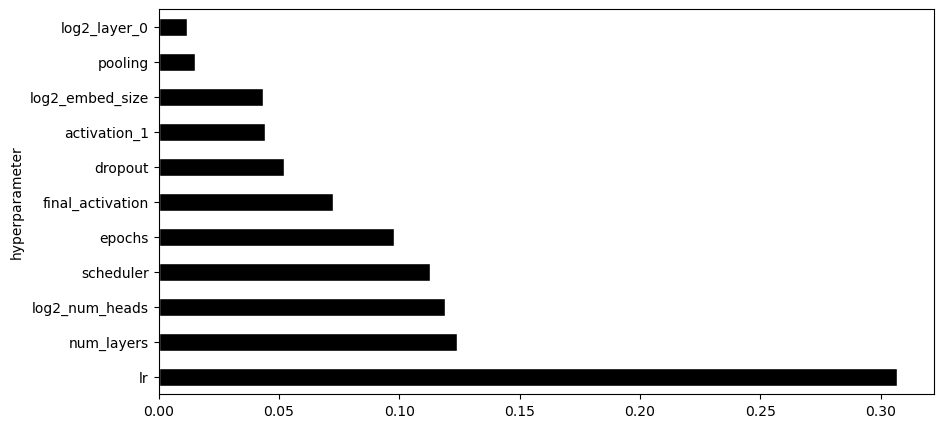

In [5]:
plt.figure(figsize=(10,5))
data.importance.plot(kind="barh", colormap = "gist_gray", edgecolor="white")

In [6]:
df = pd.DataFrame([{"value": t.value, **t.params} for t in study.get_trials()])
df['num_heads'] = 2**df.log2_num_heads.astype(int)
df.head()

,value,log2_embed_size,num_layers,log2_layer_0,activation_1,log2_layer_1,activation_2,log2_layer_2,activation_3,final_activation,...,pooling,dropout,lr,epochs,scheduler,schel_gamma,schel_step_size,schel_t_max_mod,shchel_eta_min,num_heads
0,0.326320,6,3,6,relu,7.0,identity,4.0,sigmoid,leaky_relu,...,linear,0.001278,0.000037,10,none,NaN,NaN,NaN,NaN,1
1,0.304308,3,3,2,gelu,8.0,identity,5.0,tanh,gelu,...,linear,0.070853,0.000684,6,none,NaN,NaN,NaN,NaN,4
2,0.049327,4,2,3,elu,4.0,gelu,NaN,NaN,gelu,...,linear,0.138572,0.000017,8,exponential,0.946648,NaN,NaN,NaN,1
3,-0.598469,4,1,2,relu,NaN,NaN,NaN,NaN,gelu,...,mean,0.041270,0.007712,10,exponential,0.887423,NaN,NaN,NaN,2
4,-0.833387,5,2,3,gelu,6.0,identity,NaN,NaN,sigmoid,...,mean,0.080406,0.000017,9,exponential,0.950714,NaN,NaN,NaN,2


Text(0.5, 1.0, 'C')

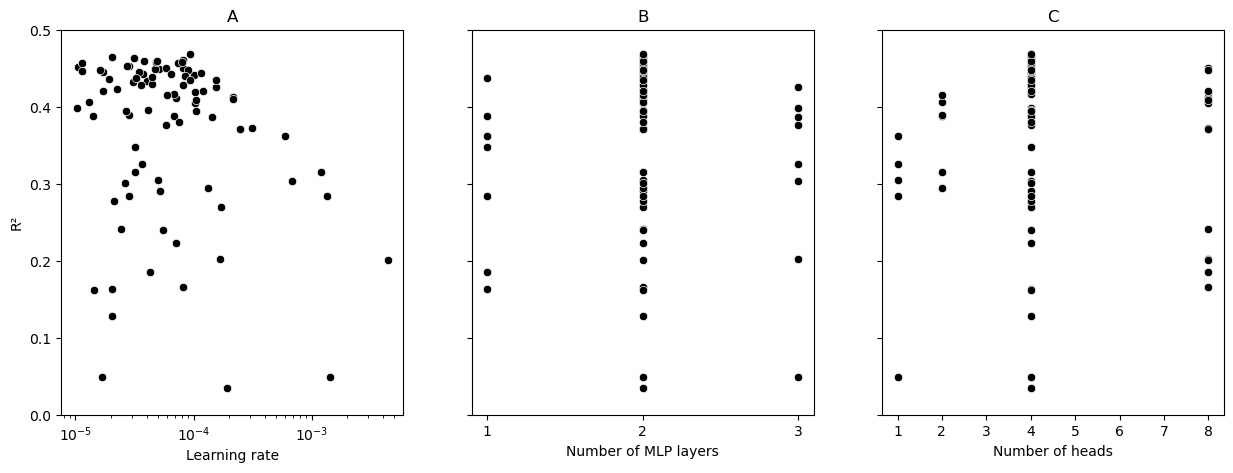

In [11]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3, sharey=True, figsize=(15,5))
sns.scatterplot(df[df.value>0], x="lr", y="value", color="black", ax=ax1)
ax1.set_xscale('log')
ax1.set_ylim(top = 0.5, bottom=0)
ax1.set_xlabel("Learning rate")
ax1.set_ylabel("R²")
ax1.set_title("A")

sns.scatterplot(df[df.value>0], x="num_layers", y="value", color="black", ax=ax2)
ax2.set_xlabel("Number of MLP layers")
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_title("B")

sns.scatterplot(df[df.value>0], x="num_heads", y="value", color="black", ax=ax3)
ax3.set_xlabel("Number of heads")
ax3.set_title("C")